# Single Unit: Energy Balances

**Prerequisites:** [00d_single_unit_cstr](./00d_single_unit_cstr.ipynb)

**Learning Objectives:**
- Derive the energy balance equation for reactors
- Understand heat of reaction and its effect on temperature
- Compare isothermal, adiabatic, and specified-duty operation
- Implement non-isothermal CSTR calculations

---

## Why Energy Balances Matter

In the CSTR tutorial, we assumed **isothermal** operation (constant temperature). In reality:

- **Exothermic reactions** release heat → temperature rises unless we remove heat
- **Endothermic reactions** absorb heat → temperature falls unless we add heat
- **Temperature affects reaction rate** (Arrhenius kinetics)

The energy balance tells us:
1. How much heat must be added/removed for isothermal operation
2. What temperature the reactor reaches if adiabatic
3. How temperature and conversion are coupled

## Deriving the Energy Balance

For a CSTR at steady state:

$$0 = \dot{Q} + \sum_{i} F_{i,in} \bar{H}_{i,in} - \sum_{i} F_{i,out} \bar{H}_{i,out}$$

where:
- $\dot{Q}$ = heat added to the system (W)
- $F_i$ = molar flow rate of species $i$ (mol/s)
- $\bar{H}_i$ = molar enthalpy of species $i$ (J/mol)

### Simplification with Heat Capacity

For ideal solutions with constant heat capacity:

$$\bar{H}_i = \bar{H}_{i}^{ref} + \int_{T_{ref}}^{T} C_{p,i} dT \approx \bar{H}_{i}^{ref} + C_{p,i}(T - T_{ref})$$

After substitution and rearrangement:

$$\boxed{\dot{Q} = \sum_i F_{i,out} C_{p,i} (T_{out} - T_{in}) + \sum_j \xi_j \Delta H_{rxn,j}}$$

where:
- $\xi_j = V \cdot r_j$ = extent of reaction $j$ (mol/s)
- $\Delta H_{rxn,j}$ = heat of reaction for reaction $j$ (J/mol)

## Heat of Reaction

The **heat of reaction** $\Delta H_{rxn}$ is the enthalpy change when the reaction occurs:

$$\Delta H_{rxn} = \sum_i \nu_i \bar{H}_{f,i}$$

where:
- $\nu_i$ = stoichiometric coefficient (negative for reactants, positive for products)
- $\bar{H}_{f,i}$ = heat of formation of species $i$

**Sign convention:**
- $\Delta H_{rxn} < 0$: Exothermic (releases heat)
- $\Delta H_{rxn} > 0$: Endothermic (absorbs heat)

In [1]:
# Setup
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from difflow import CSTR, CSTRParams, make_stream, get_flows, IdealThermo, SpeciesData

In [2]:
# Example: Exothermic reaction A -> B with ΔH_rxn = -50 kJ/mol

# Define species with heats of formation
species_data = {
    'A': SpeciesData(
        name='A', MW=50.0,
        Cp_coeffs=(50.0, 0, 0, 0),  # J/(mol·K)
        Hvap_coeffs=(30000.0, 0.38, 400.0),
        antoine_coeffs=(10.0, 2000.0, -40.0),
        Hf=0.0,  # Reference: Hf_A = 0
    ),
    'B': SpeciesData(
        name='B', MW=50.0,
        Cp_coeffs=(50.0, 0, 0, 0),
        Hvap_coeffs=(28000.0, 0.38, 380.0),
        antoine_coeffs=(10.0, 1800.0, -40.0),
        Hf=-50000.0,  # ΔH_rxn = Hf_B - Hf_A = -50 kJ/mol (exothermic)
    ),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

# Calculate heat of reaction
dH_rxn = species_data['B'].Hf - species_data['A'].Hf
print(f"Heat of reaction: ΔH_rxn = {dH_rxn/1000:.0f} kJ/mol")
print("This is EXOTHERMIC (releases heat)")

Heat of reaction: ΔH_rxn = -50 kJ/mol
This is EXOTHERMIC (releases heat)


In [3]:
# Rate function with Arrhenius temperature dependence

def rate_fn_arrhenius(C, T, params):
    """
    First-order reaction A -> B with Arrhenius kinetics.
    
    k = A * exp(-Ea / RT)
    r = k * C_A
    """
    A = params['A']     # Pre-exponential factor, 1/s
    Ea = params['Ea']   # Activation energy, J/mol
    R = 8.314           # Gas constant, J/(mol·K)
    
    k = A * jnp.exp(-Ea / (R * T))
    r = k * C['A']
    
    return jnp.array([r])

# Stoichiometry: A -> B
stoich = jnp.array([[-1.0], [1.0]])

# Kinetic parameters
rate_params = {
    'A': jnp.array(1e8),      # 1/s
    'Ea': jnp.array(50000.0), # J/mol
}

# At T = 350 K:
T_test = 350.0
k_test = float(rate_params['A'] * jnp.exp(-rate_params['Ea'] / (8.314 * T_test)))
print(f"At T = {T_test} K: k = {k_test:.4f} /s")

At T = 350.0 K: k = 3.4486 /s


## Three Modes of Operation

### 1. Isothermal Operation
Temperature is held constant. The heat duty Q is calculated to maintain T.

### 2. Adiabatic Operation  
No heat transfer (Q = 0). Temperature changes due to reaction.

### 3. Specified Heat Duty
Q is specified. Temperature is calculated.

In [4]:
# Create feed stream
F_A_in = 10.0  # mol/s
T_in = 350.0   # K
Q_vol = 0.1    # m³/s
V = 1.0        # m³

feed = make_stream({'A': F_A_in, 'B': 0.0}, T=T_in, P=101325.0)

In [5]:
# Mode 1: ISOTHERMAL
# We specify the outlet temperature = inlet temperature
# The reactor calculates Q needed

cstr_isothermal_params = CSTRParams(
    V=jnp.array(V),
    rate_fn=rate_fn_arrhenius,
    stoich=stoich,
    rate_params=rate_params,
    species_order=species_order,
    dH_rxn=jnp.array([dH_rxn]),
)

cstr_isothermal = CSTR(cstr_isothermal_params, thermo=thermo, mode='isothermal')
outlet_iso, info_iso = cstr_isothermal(feed, T_spec=T_in, volumetric_flow=Q_vol)

print("MODE 1: ISOTHERMAL")
print("=" * 50)
print(f"Inlet T  = {T_in} K")
print(f"Outlet T = {float(outlet_iso['T']):.1f} K")
print(f"Conversion = {float(info_iso['conversion']['A'])*100:.1f}%")
print(f"Heat duty Q = {float(info_iso['Q'])/1000:.2f} kW")
print(f"\n(Negative Q means heat must be REMOVED - cooling required)")

MODE 1: ISOTHERMAL
Inlet T  = 350.0 K
Outlet T = 350.0 K
Conversion = 97.2%
Heat duty Q = -485.91 kW

(Negative Q means heat must be REMOVED - cooling required)


In [6]:
# Mode 2: ADIABATIC
# No heat transfer - temperature changes with reaction

cstr_adiabatic = CSTR(cstr_isothermal_params, thermo=thermo, mode='adiabatic')
outlet_adi, info_adi = cstr_adiabatic(feed, volumetric_flow=Q_vol)

print("MODE 2: ADIABATIC")
print("=" * 50)
print(f"Inlet T  = {T_in} K")
print(f"Outlet T = {float(outlet_adi['T']):.1f} K")
print(f"Conversion = {float(info_adi['conversion']['A'])*100:.1f}%")
print(f"Heat duty Q = {float(info_adi['Q'])/1000:.2f} kW (should be ~0)")
print(f"\nTemperature rise: ΔT = {float(outlet_adi['T']) - T_in:.1f} K")
print(f"(Exothermic reaction heats up the mixture)")

MODE 2: ADIABATIC
Inlet T  = 350.0 K
Outlet T = 1350.0 K
Conversion = 100.0%
Heat duty Q = 0.00 kW (should be ~0)

Temperature rise: ΔT = 1000.0 K
(Exothermic reaction heats up the mixture)


In [7]:
# Mode 3: SPECIFIED HEAT DUTY
# We provide some cooling, but not enough for isothermal operation

Q_specified = -15000.0  # W (15 kW cooling)

cstr_specified = CSTR(cstr_isothermal_params, thermo=thermo, mode='specified_duty')
outlet_spec, info_spec = cstr_specified(feed, Q_spec=Q_specified, volumetric_flow=Q_vol)

print("MODE 3: SPECIFIED HEAT DUTY")
print("=" * 50)
print(f"Inlet T  = {T_in} K")
print(f"Outlet T = {float(outlet_spec['T']):.1f} K")
print(f"Conversion = {float(info_spec['conversion']['A'])*100:.1f}%")
print(f"Heat duty Q = {Q_specified/1000:.2f} kW (specified)")
print(f"\nTemperature rise: ΔT = {float(outlet_spec['T']) - T_in:.1f} K")

MODE 3: SPECIFIED HEAT DUTY
Inlet T  = 350.0 K
Outlet T = 1320.0 K
Conversion = 100.0%
Heat duty Q = -15.00 kW (specified)

Temperature rise: ΔT = 970.0 K


In [8]:
# Compare all three modes

print("\nCOMPARISON OF OPERATING MODES")
print("=" * 60)
print(f"{'Mode':<20} {'T_out (K)':<12} {'X (%)':<10} {'Q (kW)':<12}")
print("-" * 60)
print(f"{'Isothermal':<20} {float(outlet_iso['T']):<12.1f} {float(info_iso['conversion']['A'])*100:<10.1f} {float(info_iso['Q'])/1000:<12.2f}")
print(f"{'Adiabatic':<20} {float(outlet_adi['T']):<12.1f} {float(info_adi['conversion']['A'])*100:<10.1f} {float(info_adi['Q'])/1000:<12.2f}")
print(f"{'Specified Q=-15kW':<20} {float(outlet_spec['T']):<12.1f} {float(info_spec['conversion']['A'])*100:<10.1f} {Q_specified/1000:<12.2f}")


COMPARISON OF OPERATING MODES
Mode                 T_out (K)    X (%)      Q (kW)      
------------------------------------------------------------
Isothermal           350.0        97.2       -485.91     
Adiabatic            1350.0       100.0      0.00        
Specified Q=-15kW    1320.0       100.0      -15.00      


## Visualizing the Energy Balance

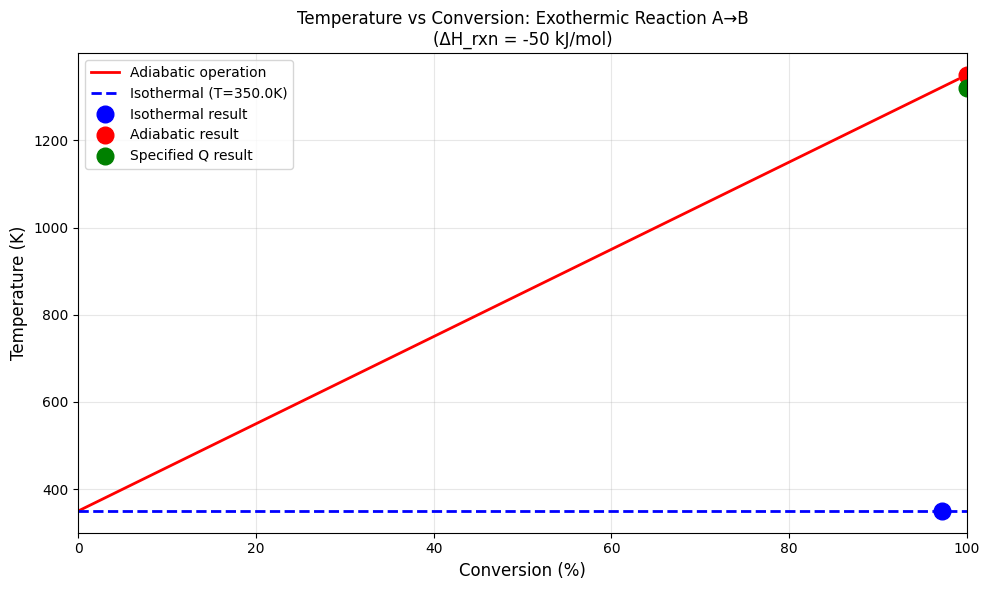

In [9]:
# Plot temperature vs conversion for adiabatic operation

# Adiabatic temperature rise: ΔT = -ξ·ΔH_rxn / (F·Cp)
# where ξ = F_A_in · X is the extent of reaction

X_range = np.linspace(0, 0.99, 100)
Cp_avg = 50.0  # J/(mol·K)
F_total = F_A_in  # mol/s

# Adiabatic temperature: T = T_in + (-ΔH_rxn)·X·F_A_in / (F_total·Cp)
T_adiabatic = T_in + (-dH_rxn) * X_range * F_A_in / (F_total * Cp_avg)

fig, ax = plt.subplots(figsize=(10, 6))

# Adiabatic line
ax.plot(X_range * 100, T_adiabatic, 'r-', linewidth=2, label='Adiabatic operation')

# Isothermal line
ax.axhline(y=T_in, color='b', linestyle='--', linewidth=2, label=f'Isothermal (T={T_in}K)')

# Mark operating points
ax.plot(float(info_iso['conversion']['A'])*100, float(outlet_iso['T']), 'bo', markersize=12, label='Isothermal result')
ax.plot(float(info_adi['conversion']['A'])*100, float(outlet_adi['T']), 'ro', markersize=12, label='Adiabatic result')
ax.plot(float(info_spec['conversion']['A'])*100, float(outlet_spec['T']), 'go', markersize=12, label='Specified Q result')

ax.set_xlabel('Conversion (%)', fontsize=12)
ax.set_ylabel('Temperature (K)', fontsize=12)
ax.set_title('Temperature vs Conversion: Exothermic Reaction A→B\n(ΔH_rxn = -50 kJ/mol)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()


## The Raw Equations

Let's implement the energy balance from scratch to see what difflow is doing.

In [10]:
def cstr_with_energy_balance_raw(F_in, T_in, V, Q_vol, k_params, dH_rxn, Cp, mode='isothermal', Q_spec=None, T_spec=None):
    """
    Solve CSTR with energy balance from first principles.
    
    Equations:
        Mass: F_A_out = F_A_in - V·r(C_A, T)
        Energy: Q = F_total·Cp·(T_out - T_in) + ξ·ΔH_rxn
        
    Mode:
        'isothermal': T_out = T_in, solve for Q
        'adiabatic': Q = 0, solve for T_out
        'specified_duty': Q given, solve for T_out
    """
    F_A_in = F_in[0]
    A, Ea = k_params['A'], k_params['Ea']
    R = 8.314
    
    if mode == 'isothermal':
        T_out = T_spec if T_spec else T_in
        
        # Solve mass balance at T_out
        k = A * np.exp(-Ea / (R * T_out))
        tau = V / Q_vol
        C_A_in = F_A_in / Q_vol
        
        # For first-order: C_A = C_A_in / (1 + k·τ)
        C_A_out = C_A_in / (1 + k * tau)
        F_A_out = C_A_out * Q_vol
        
        # Extent of reaction
        xi = F_A_in - F_A_out  # mol/s converted
        
        # Energy balance: Q = F·Cp·ΔT + ξ·ΔH_rxn
        # For isothermal, ΔT = 0
        Q = xi * dH_rxn
        
        return F_A_out, T_out, Q
    
    elif mode == 'adiabatic':
        # Need to solve coupled mass and energy balance
        # Iterate to find T_out
        
        T_out = T_in  # Initial guess
        F_total = F_A_in
        
        for _ in range(100):
            k = A * np.exp(-Ea / (R * T_out))
            tau = V / Q_vol
            C_A_in = F_A_in / Q_vol
            C_A_out = C_A_in / (1 + k * tau)
            F_A_out = C_A_out * Q_vol
            xi = F_A_in - F_A_out
            
            # Adiabatic: Q = 0, so F·Cp·(T_out - T_in) = -ξ·ΔH_rxn
            T_out_new = T_in + (-dH_rxn) * xi / (F_total * Cp)
            
            if abs(T_out_new - T_out) < 1e-6:
                break
            T_out = 0.5 * T_out + 0.5 * T_out_new  # Damped update
        
        conversion = (F_A_in - F_A_out) / F_A_in
        return F_A_out, T_out, 0.0, conversion

# Test ISOTHERMAL mode
F_A_out_raw, T_out_raw, Q_raw = cstr_with_energy_balance_raw(
    F_in=[F_A_in], T_in=T_in, V=V, Q_vol=Q_vol,
    k_params={'A': float(rate_params['A']), 'Ea': float(rate_params['Ea'])},
    dH_rxn=dH_rxn, Cp=50.0, mode='isothermal'
)

print("Raw Implementation vs difflow (Isothermal)")
print("=" * 50)
print(f"{'Quantity':<20} {'Raw':<15} {'difflow':<15}")
print("-" * 50)
print(f"{'F_A_out (mol/s)':<20} {F_A_out_raw:<15.4f} {float(get_flows(outlet_iso)['A']):<15.4f}")
print(f"{'T_out (K)':<20} {T_out_raw:<15.1f} {float(outlet_iso['T']):<15.1f}")
print(f"{'Q (kW)':<20} {Q_raw/1000:<15.2f} {float(info_iso['Q'])/1000:<15.2f}")

# Test ADIABATIC mode
F_A_out_raw_adi, T_out_raw_adi, Q_raw_adi, X_raw_adi = cstr_with_energy_balance_raw(
    F_in=[F_A_in], T_in=T_in, V=V, Q_vol=Q_vol,
    k_params={'A': float(rate_params['A']), 'Ea': float(rate_params['Ea'])},
    dH_rxn=dH_rxn, Cp=50.0, mode='adiabatic'
)

print("\n\nRaw Implementation vs difflow (Adiabatic)")
print("=" * 50)
print(f"{'Quantity':<20} {'Raw':<15} {'difflow':<15}")
print("-" * 50)
print(f"{'F_A_out (mol/s)':<20} {F_A_out_raw_adi:<15.4f} {float(get_flows(outlet_adi)['A']):<15.4f}")
print(f"{'T_out (K)':<20} {T_out_raw_adi:<15.1f} {float(outlet_adi['T']):<15.1f}")
print(f"{'Conversion (%)':<20} {X_raw_adi*100:<15.1f} {float(info_adi['conversion']['A'])*100:<15.1f}")

print("\n✓ Both implementations agree!")

Raw Implementation vs difflow (Isothermal)
Quantity             Raw             difflow        
--------------------------------------------------
F_A_out (mol/s)      0.2818          0.2818         
T_out (K)            350.0           350.0          
Q (kW)               -485.91         -485.91        


Raw Implementation vs difflow (Adiabatic)
Quantity             Raw             difflow        
--------------------------------------------------
F_A_out (mol/s)      0.0000          0.0000         
T_out (K)            1350.0          1350.0         
Conversion (%)       100.0           100.0          

✓ Both implementations agree!


## Try It Yourself!

### Exercise 1: Endothermic Reaction
Change the heat of reaction to +30 kJ/mol (endothermic). What happens to the adiabatic temperature? Does conversion go up or down?

In [11]:
# Your solution here

### Exercise 2: Multiple Steady States
Exothermic reactions in adiabatic CSTRs can have multiple steady states. Try varying the inlet temperature from 300K to 400K and plot the outlet temperature. Do you see any jumps?

In [12]:
# Your solution here

## End-of-Tutorial Problems

### Problem 1: Heat Duty Calculation
For the reaction A → B with ΔH_rxn = -80 kJ/mol:
- Feed: 20 mol/s pure A at 400 K
- Conversion: 60%
- Outlet temperature: 400 K (isothermal)

Calculate the heat duty required (in kW).

### Problem 2: Adiabatic Temperature Rise
For the same reaction, if operated adiabatically with Cp = 100 J/(mol·K), what is the outlet temperature at 60% conversion?

### Problem 3: Cooling Jacket Design
If the cooling water can remove heat at a rate of -50 kW, what is the maximum conversion achievable while keeping T_out ≤ 420 K?

---

## Key Takeaways

1. **Energy balance:** $Q = F \cdot C_p \cdot \Delta T + \xi \cdot \Delta H_{rxn}$
2. **Exothermic reactions** ($\Delta H_{rxn} < 0$) release heat → temperature rises in adiabatic operation
3. **Three operating modes:** Isothermal, adiabatic, specified duty
4. **Temperature affects rate:** Higher T → faster reaction (Arrhenius)
5. **Coupled equations:** Mass and energy balances must be solved together

---

## Next Steps

In the next notebook (**[00f: Single Unit - The PFR](./00f_single_unit_pfr.ipynb)**), we'll explore:
- The plug flow reactor (PFR) design equation
- Why it's an ODE instead of algebraic
- Comparison of CSTR vs PFR performance